In [1]:
import pandas as pd
import networkx as nx
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
G=nx.parse_edgelist(['Univ ProfA', 
                     'Univ ProfB',
                     'ProfA StudentA',
                     'StudentA Univ',
                     'ProfB StudentB',
                     'StudentB ProfB'],
                    create_using=nx.DiGraph)

In [3]:
def plot_graph (G,title):
    # Use weighted degrees in next line
    degrees = pd.DataFrame(list(G.degree(weight='weight')),columns=["node","degree"])
    plt.figure(figsize=(20,10))
    
    # Do undirected layout in next line, for some reason spring layout better than if directed.
    layout = nx.spring_layout(G.to_undirected(), iterations=30) 
    #layout = nx.kamada_kawai_layout(G)
    
    # Plot settings 
    ax = plt.gca()
    #ax.axis('off') # uncomment if you don't want the bounding box
    ax.set_title(title)
    
    # Place nodes, edges and labels
    nx.draw(G, with_labels=True, pos=layout,node_size=2000)
    nx.draw_networkx_edges(G, pos=layout, arrows=True, arrowsize=60)
    plt.show()

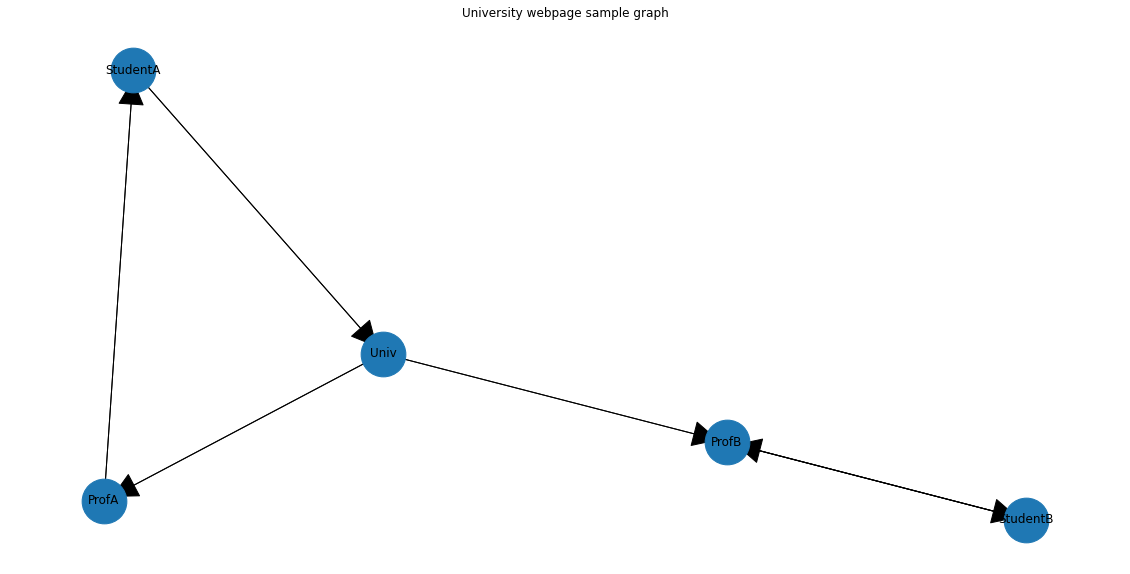

In [4]:
plot_graph(G,'University webpage sample graph')

In [5]:
for node in G.nodes:
    print('Personalization for', node)
    print(nx.pagerank(G,personalization={node:1}))

Personalization for Univ
{'Univ': 0.21646973934010472, 'ProfA': 0.09199963921671242, 'ProfB': 0.3315312123742784, 'StudentA': 0.07819969333963371, 'StudentB': 0.28179971572927076}
Personalization for ProfA
{'Univ': 0.15639938666982717, 'ProfA': 0.21646973933538458, 'ProfB': 0.23953157316228604, 'StudentA': 0.18399927843342484, 'StudentB': 0.20360002239907732}
Personalization for ProfB
{'Univ': 3.2154811625966715e-13, 'ProfA': 3.2154811625966715e-13, 'ProfB': 0.540541536855293, 'StudentA': 3.2154811625966715e-13, 'StudentB': 0.45945846314374233}
Personalization for StudentA
{'Univ': 0.183999278434286, 'ProfA': 0.07819969333517368, 'ProfB': 0.28179966790438554, 'StudentA': 0.21646973933426933, 'StudentB': 0.23953162099188544}
Personalization for StudentB
{'Univ': 1.1779098738645718e-10, 'ProfA': 1.1779098738645718e-10, 'ProfB': 0.45946057203035434, 'StudentA': 1.1779098738645718e-10, 'StudentB': 0.5405394276162728}


In [6]:
nx.simrank_similarity(G,importance_factor=0.8)

{'Univ': {'Univ': 1,
  'ProfA': 0.0,
  'ProfB': 0.1323363991265798,
  'StudentA': 0.0,
  'StudentB': 0.03387811817640443},
 'ProfA': {'Univ': 0.0,
  'ProfA': 1,
  'ProfB': 0.4135512472705618,
  'StudentA': 0.0,
  'StudentB': 0.10586911930126384},
 'ProfB': {'Univ': 0.1323363991265798,
  'ProfA': 0.4135512472705618,
  'ProfB': 1,
  'StudentA': 0.04234764772050554,
  'StudentB': 0.08822426608438655},
 'StudentA': {'Univ': 0.0,
  'ProfA': 0.0,
  'ProfB': 0.04234764772050554,
  'StudentA': 1,
  'StudentB': 0.3308409978164495},
 'StudentB': {'Univ': 0.03387811817640443,
  'ProfA': 0.10586911930126384,
  'ProfB': 0.08822426608438655,
  'StudentA': 0.3308409978164495,
  'StudentB': 1}}

In [7]:
def simrank_step(u, v, C):
    in_neighbors_u = list(G.predecessors(u))
    in_neighbors_v = list(G.predecessors(v))
    scale = C / (len(in_neighbors_u) * len(in_neighbors_v))
    return scale * sum(simrank[(w, x)]
                       for w in in_neighbors_u for x in in_neighbors_v)

In [8]:
simrank={(u,v):1 if u==v else 0 for u in G.nodes for v in G.nodes}
C=0.8
for i in range(10):
    print('ITERATION',i)
    for u in G.nodes:
        for v in G.nodes:
            if u!= v:
                simrank[(u,v)]=simrank_step(u, v, C)
                print('   ',u,v, simrank[(u,v)])

ITERATION 0
    Univ ProfA 0.0
    Univ ProfB 0.0
    Univ StudentA 0.0
    Univ StudentB 0.0
    ProfA Univ 0.0
    ProfA ProfB 0.4
    ProfA StudentA 0.0
    ProfA StudentB 0.0
    ProfB Univ 0.0
    ProfB ProfA 0.4
    ProfB StudentA 0.0
    ProfB StudentB 0.0
    StudentA Univ 0.0
    StudentA ProfA 0.0
    StudentA ProfB 0.0
    StudentA StudentB 0.32000000000000006
    StudentB Univ 0.0
    StudentB ProfA 0.0
    StudentB ProfB 0.0
    StudentB StudentA 0.32000000000000006
ITERATION 1
    Univ ProfA 0.0
    Univ ProfB 0.12800000000000003
    Univ StudentA 0.0
    Univ StudentB 0.0
    ProfA Univ 0.0
    ProfA ProfB 0.4
    ProfA StudentA 0.0
    ProfA StudentB 0.10240000000000003
    ProfB Univ 0.12800000000000003
    ProfB ProfA 0.4
    ProfB StudentA 0.0
    ProfB StudentB 0.051200000000000016
    StudentA Univ 0.0
    StudentA ProfA 0.0
    StudentA ProfB 0.04096000000000002
    StudentA StudentB 0.32000000000000006
    StudentB Univ 0.0
    StudentB ProfA 0.10240000000000003
